Processing turnover columns...

--- Data Summary ---
Total Rows:  446
Human Rows:  0
Agent Rows:  173

--- Statistical Comparison (Human vs Agent) ---

Metric: turnover_c5 - Missing data for one or both groups.

Metric: turnover_c10 - Missing data for one or both groups.

Metric: turnover_c20 - Missing data for one or both groups.

Metric: turnover_m1 - Missing data for one or both groups.

Metric: turnover_m3 - Missing data for one or both groups.


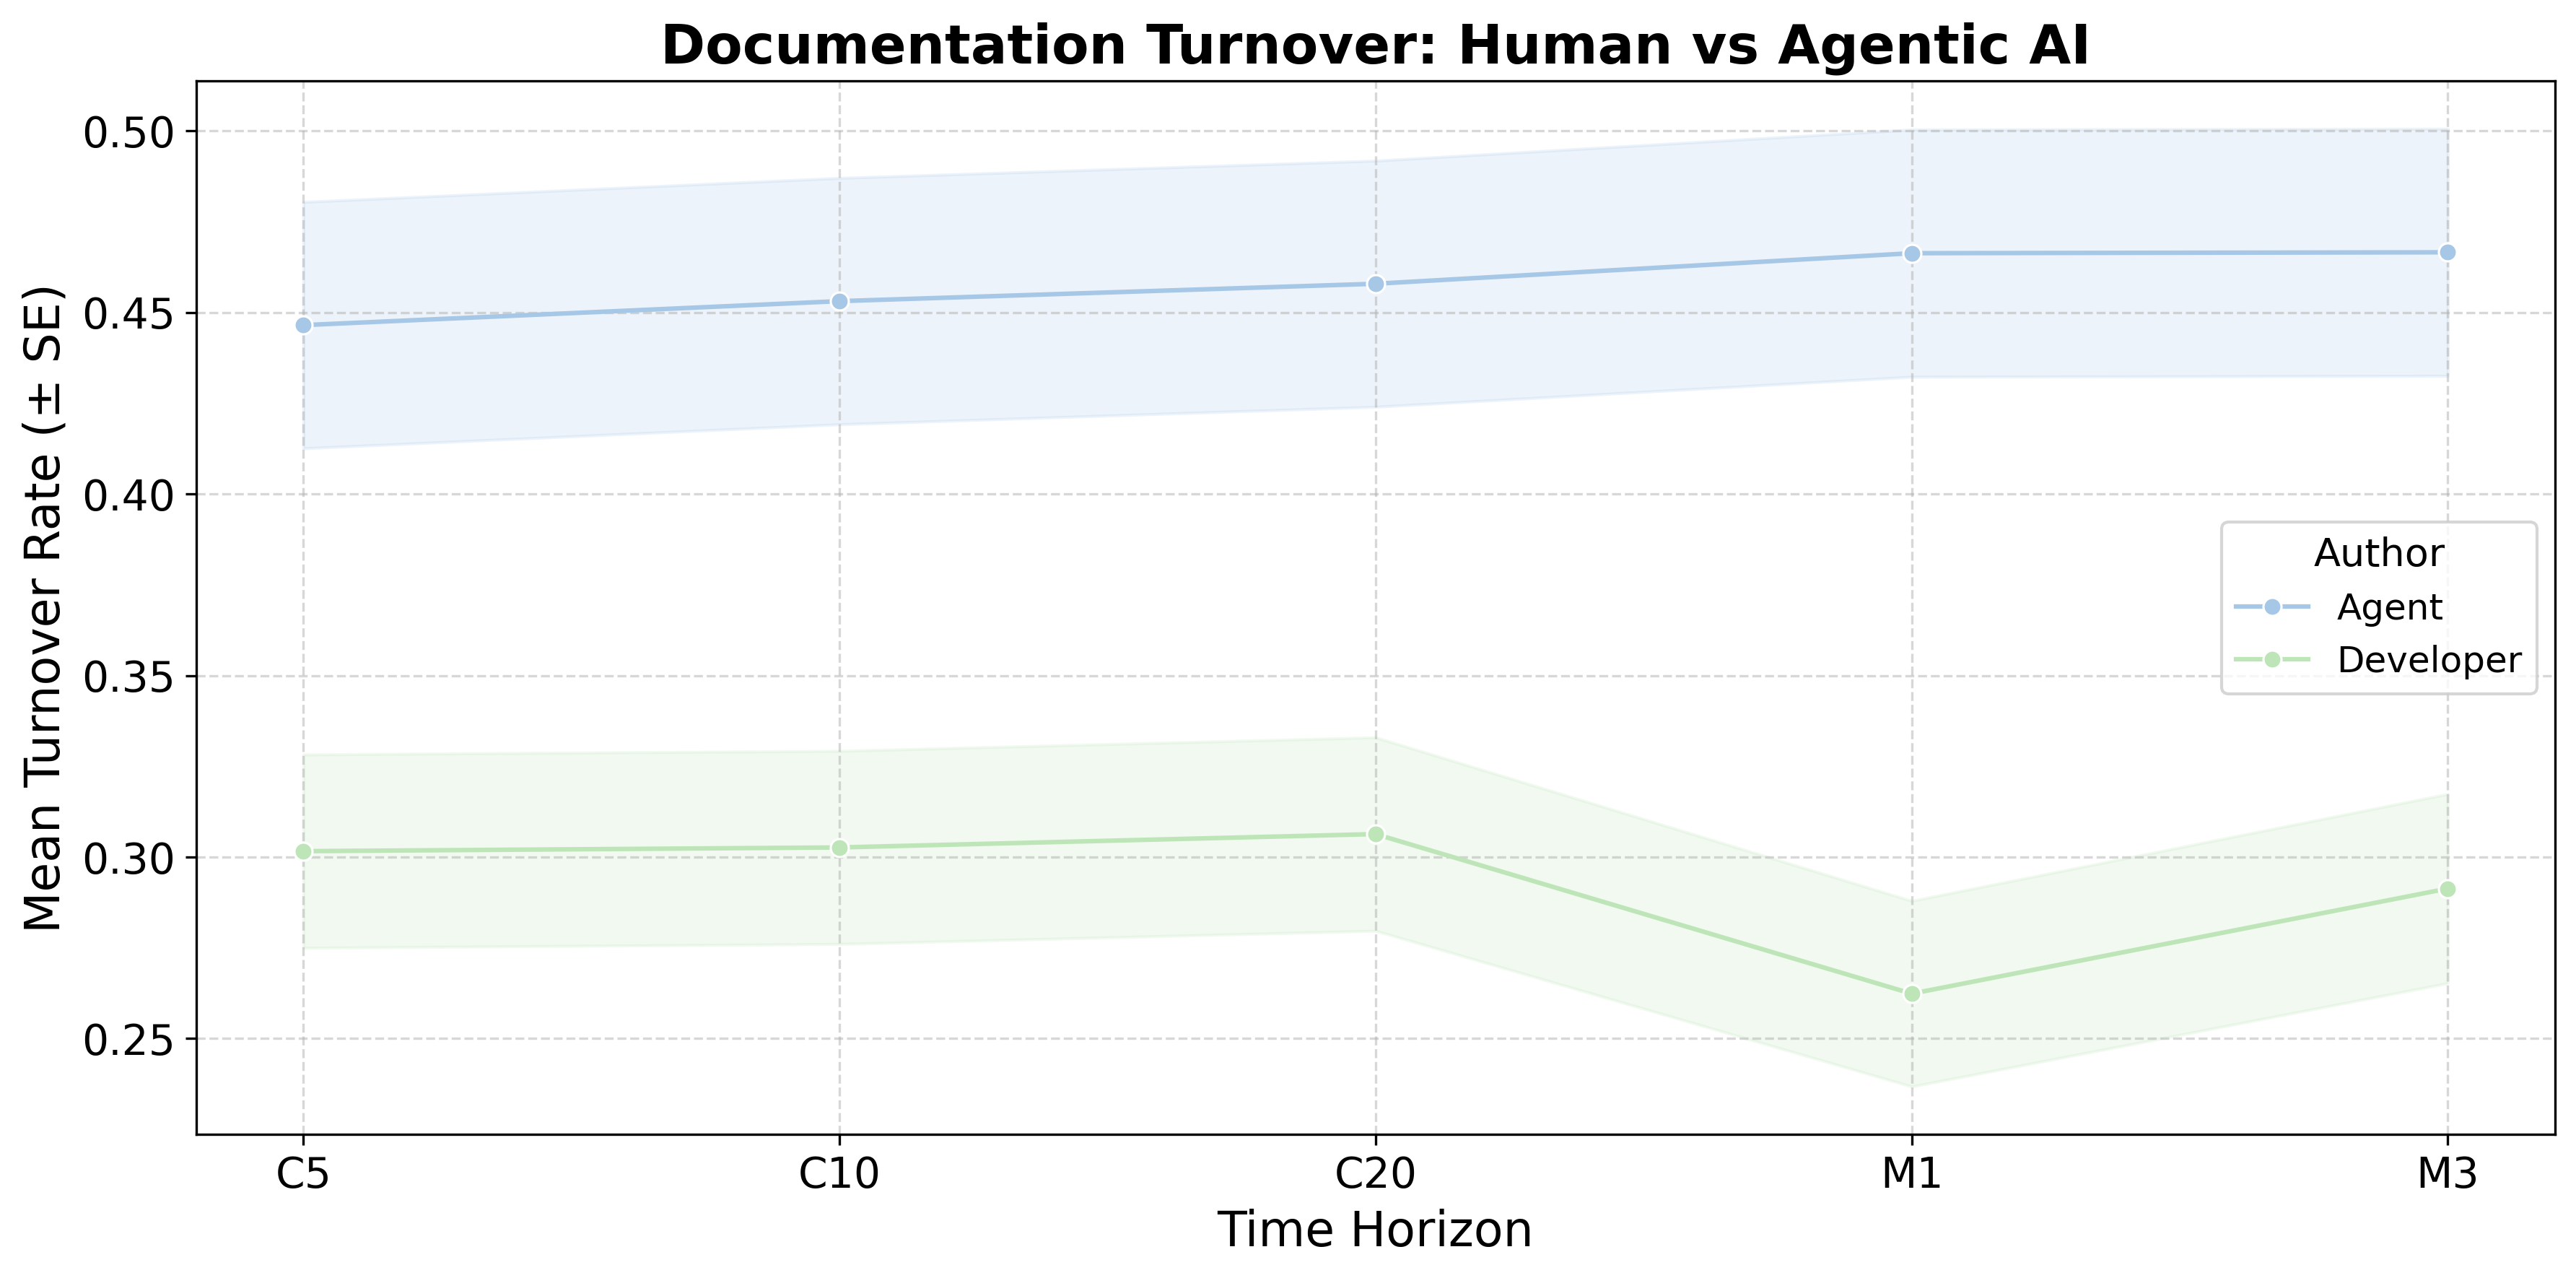

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import ast

# 1. LOAD DATA
file_path = r"G:\663P\dataset\data\updated_dataset_2_metrics_f.csv"
df = pd.read_csv(file_path)

# 2. HELPER FUNCTION FOR TUPLES
def extract_turnover_value(val):
    """
    Handles cases where turnover is a tuple (sha, value) or a string "(sha, value)".
    Returns the numeric value, or NaN if invalid/-1.
    """
    if pd.isna(val) or val == -1 or val == "-1":
        return np.nan
    
    try:
        # If it's a string representation of a tuple: "(sha, 0.5)"
        if isinstance(val, str) and "(" in val:
            parsed = ast.literal_eval(val)
            val = parsed[1]
        # If it's already a tuple/list
        elif isinstance(val, (tuple, list)):
            val = val[1]
        
        # Final conversion to float
        num = float(val)
        return num if num >= 0 else np.nan
    except (ValueError, SyntaxError, IndexError, TypeError):
        return np.nan

# 3. CLEANING & PROCESSING
# Define columns
turnover_cols = ["turnover_c5", "turnover_c10", "turnover_c20", "turnover_m1", "turnover_m3"]
doc_quality_cols = ["doc_entropy", "doc_code_overlap", "doc_redundancy"]

# Drop rows with no documentation baseline
df = df.dropna(subset=doc_quality_cols)
df = df[df['doc_lines'] > 0].copy()

# Process turnover columns (Extract numbers from tuples and filter -1)
print("Processing turnover columns...")
for col in turnover_cols:
    df[col] = df[col].apply(extract_turnover_value)

# Drop rows that have NaNs in the turnover columns after extraction
df_turn = df.dropna(subset=turnover_cols).copy()
df_turn["group"] = df_turn["group"].str.lower().map({
    "human": "Developer",
    "agent": "Agent"
})
# 4. SPLIT BY GROUP (Human vs Agent)
# Ensure case-insensitivity for the group label
df_h = df_turn[df_turn['group'].str.lower() == 'human'].copy()
df_a = df_turn[df_turn['group'].str.lower() == 'agent'].copy()

print(f"\n--- Data Summary ---")
print(f"Total Rows:  {len(df_turn)}")
print(f"Human Rows:  {len(df_h)}")
print(f"Agent Rows:  {len(df_a)}")

# 5. STATISTICAL ANALYSIS (Mann-Whitney U)
print("\n--- Statistical Comparison (Human vs Agent) ---")
for col in turnover_cols:
    group_h = df_h[col]
    group_a = df_a[col]
    
    if not group_h.empty and not group_a.empty:
        stat, p = mannwhitneyu(group_h, group_a, alternative='two-sided')
        n1 = len(group_h)
        n2 = len(group_a)
        e = 1 - (2 * stat) / (n1 * n2)
        print(f"\nMetric: {col}")
        print(f"  Human Median: {group_h.median():.4f} (Mean: {group_h.mean():.4f})")
        print(f"  Agent Median: {group_a.median():.4f} (Mean: {group_a.mean():.4f})")
        print(f"  P-value:      {p:.6e}")
        print(f"  efffect size:      {e:.6e}")
    else:
        print(f"\nMetric: {col} - Missing data for one or both groups.")

# 6. VISUALIZATION

# Reshape for Seaborn lineplot
df_melt = df_turn.melt(
    id_vars=["group"],
    value_vars=turnover_cols,
    var_name="time_interval",
    value_name="turnover_value"
)

# 🔥 Clean + readable labels
turnover_label_map = {
    "turnover_c5": "C5",
    "turnover_c10": "C10",
    "turnover_c20": "C20",
    "turnover_m1": "M1",
    "turnover_m3": "M3"
}

df_melt["time_interval"] = df_melt["time_interval"].map(turnover_label_map)

# 🔥 enforce correct ordering on x-axis
order = ["C5", "C10", "C20", "M1", "M3"]
df_melt["time_interval"] = pd.Categorical(
    df_melt["time_interval"],
    categories=order,
    ordered=True
)

plt.figure(figsize=(12, 6), dpi=300)

ax = sns.lineplot(
    data=df_melt,
    x="time_interval",
    y="turnover_value",
    hue="group",
    marker="o",
    estimator="mean",
    errorbar="se",
    palette={"Agent": "#A7C7E7", "Developer": "#BDE5B8"}
)

ax.set_title(
    "Documentation Turnover: Human vs Agentic AI",
    fontsize=18,
    fontweight='bold'
)

ax.set_ylabel("Mean Turnover Rate (± SE)", fontsize=16)
ax.set_xlabel("Time Horizon", fontsize=16)

# ticks
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

# legend (clean + centered)
ax.legend(title="Author", fontsize=12, title_fontsize=13)

ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [2]:
turnover_cols = ["turnover_c5", "turnover_c10", "turnover_c20", "turnover_m1", "turnover_m3"]

# remove invalid values
for col in turnover_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df_turn = df.dropna(subset=turnover_cols)

In [3]:
for col in turnover_cols:
    a = df_turn[df_turn["group"] == "agent"][col]
    h = df_turn[df_turn["group"] == "human"][col]
    
    stat, p = mannwhitneyu(a, h)
    
    print(f"\n=== {col} ===")
    print(f"Agent mean: {a.mean():.4f}")
    print(f"Human mean: {h.mean():.4f}")
    print(f"p-value: {p:.6f}")


=== turnover_c5 ===
Agent mean: 0.4465
Human mean: 0.3016
p-value: 0.001713

=== turnover_c10 ===
Agent mean: 0.4531
Human mean: 0.3027
p-value: 0.001280

=== turnover_c20 ===
Agent mean: 0.4579
Human mean: 0.3063
p-value: 0.001348

=== turnover_m1 ===
Agent mean: 0.4663
Human mean: 0.2624
p-value: 0.000002

=== turnover_m3 ===
Agent mean: 0.4666
Human mean: 0.2913
p-value: 0.000102


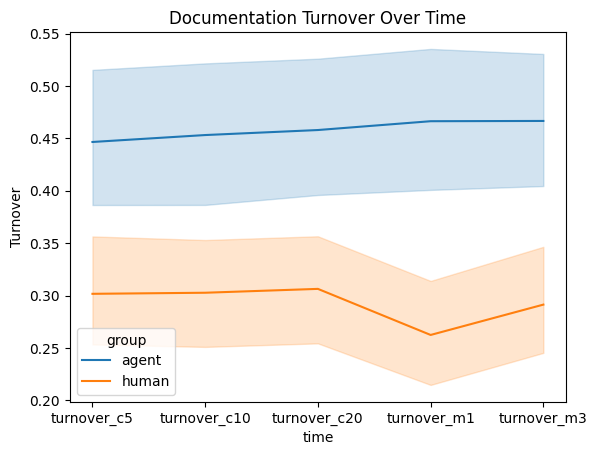

In [4]:
# reshape for plotting
df_melt = df_turn.melt(
    id_vars=["group"],
    value_vars=turnover_cols,
    var_name="time",
    value_name="turnover"
)

plt.figure()
sns.lineplot(data=df_melt, x="time", y="turnover", hue="group", estimator="mean")
plt.title("Documentation Turnover Over Time")
plt.ylabel("Turnover")
plt.show()